In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
#%%bash
#python -m numpy.f2py -c upwind.f95 -m upwind_module

In [70]:
import upwind_module
from Nozzle_2D_checkpoint4_2 import Nozzle
import numpy as np
import matplotlib.pyplot as plt

In [71]:
vanleer = upwind_module.upwind_module.vanleer_flux

In [72]:
SUPERCOARSE = Nozzle("inputs/Medium_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000

# RUN MEDIUM SIMULATION
self.set_arrays()
self.set_curved_geometry()
self.set_normals()
self.compute_all_areas()
self.is_foil = False




In [73]:
#nx, ny = self.V.shape[1], self.V.shape[2]

# Coordinates (normalized 0–1)
#x = np.linspace(0, 1, nx)
#y = np.linspace(0, 1, ny)
#X, Y = np.meshgrid(x, y, indexing="ij")

# Center point
#x0, y0 = 0.5, 0.5

# Radial distance from center
#r = np.sqrt((X - x0)**2 + (Y - y0)**2)

# Gaussian distribution, peak 0.5 in the middle, decaying outward
#mach = .1+ 0*r # -0.1 * np.exp(- (r**2) / (0.1**2))

In [74]:
mach = .1*np.ones_like(self.V[0])
T = self.total_T(self.gamma, mach, self.T0)
p_bndry = self.total_p(self.gamma, mach, self.p0)
rho_bndry = self.total_density(p_bndry, self.R, T)
u_bndry =  self.total_velocity(self.gamma, mach, self.R, T)
v_bndry = 0*self.total_velocity(self.gamma, mach, self.R, T)
self.V = np.array([rho_bndry, 0*u_bndry, v_bndry, p_bndry])
self.U = self.primitive_to_conserved(self.V)

In [75]:
#mach = .5*np.ones_like(self.V[0,:,0:20])

#T = self.total_T(self.gamma, mach, self.T0)
#p_bndry = self.total_p(self.gamma, mach, self.p0)
#rho_bndry = self.total_density(p_bndry, self.R, T)
#u_bndry =  self.total_velocity(self.gamma, mach, self.R, T)
#$v_bndry = 0*self.total_velocity(self.gamma, mach, self.R, T)



#self.V[:, :, 0:20] = np.array([rho_bndry, 0*u_bndry, v_bndry, p_bndry])
#self.V[1, :, 0:20] = u_bndry
#self.U = self.primitive_to_conserved(self.V)

In [76]:
ncells = self.V[1].shape[0]
halfcells = int(ncells/2)
gamma=1.4
p0 = .1*np.ones_like(self.V[0])
u0 = 0*np.ones_like(self.V[0])
r0 = .125*np.ones_like(self.V[0])

p0[:halfcells,:halfcells] = 1.0  ;
u0[:halfcells,:halfcells] = 0.0  ; 
r0[:halfcells,:halfcells] = 1.0  ; 

E0 = p0/((gamma-1.)*r0)+0.5*u0**2 # Total Energy density
a0 = np.sqrt(gamma*p0/r0)            # Speed of sound
q  = np.array([r0,r0*u0,r0*u0,r0*E0]) 
self.U= q
self.V = self.conserved_to_primitive(self.U)

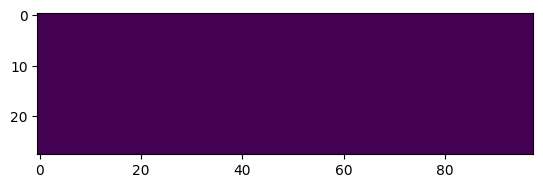

In [77]:
self.V = self.conserved_to_primitive(self.U)
plt.imshow(self.V[2])

In [78]:
# V[:,(UD),(LR)]

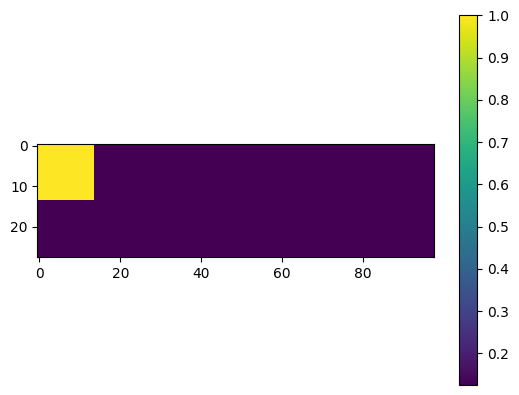

In [79]:
plt.imshow(self.U[0])
plt.colorbar()

In [80]:
self.V.shape

(4, 28, 98)

In [81]:

# #V = np.zeros((self.V.shape[0],self.V.shape[1]+2,self.V.shape[2]+2))
# V = self.V
# #V[:,1:-1,1:-1] = self.V
# #V[:,0,:] = V[:,1,:]
# #V[:,-1,:] = V[:,-2,:]
# #V[:,:,0] = V[:,:,1]
# #V[:,:,-1] = V[:,:,-2]
# for i in range(1,self.NI-1):
#     for j in range(1,self.NJ-1):
        
#         #Flux left

#         FL_cell_L = V[:,i,j-1]
#         FL_cell_R = V[:,i,j]
#         FL = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_L[i,j],ny_L[i,j]) + self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_L[i,j],ny_L[i,j])

#         #Flux right
#         FR_cell_L = V[:,i,j]
#         FR_cell_R = V[:,i,j+1]
#         FR = self.f_convective_cell(FR_cell_L,FR_cell_R,nx_R[i,j],ny_R[i,j]) + self.f_pressure_flux_cell(FR_cell_L,FR_cell_R,nx_R[i,j],ny_R[i,j])

#         # Flux down
#         FD_cell_L = V[:, i-1, j]
#         FD_cell_R = V[:, i, j]
#         FD = self.f_convective_cell(FD_cell_L, FD_cell_R, nx_D[i,j], ny_D[i,j]) + self.f_pressure_flux_cell(FD_cell_L, FD_cell_R, nx_D[i, j], ny_D[i, j])

#         # Flux up
#         FU_cell_L = V[:, i, j]
#         FU_cell_R = V[:, i+1, j]
#         FU = self.f_convective_cell(FU_cell_L, FU_cell_R, nx_U[i,j], ny_U[i,j]) + self.f_pressure_flux_cell(FU_cell_L, FU_cell_R, nx_U[i, j], ny_U[i, j])
        


#         #residual[:, i, j] = self.A_left[:,i, j]* FL + self.A_right[:,i, j]* FR + self.A_bottom[:,i, j] * FD+ self.A_top[:,i, j]   * FU

 

In [82]:
residual = np.zeros_like(self.V)
V = self.V
nx_L,ny_L = self.get_normal_directions(direction="left")
nx_R,ny_R = self.get_normal_directions(direction="right")
nx_U,ny_U = self.get_normal_directions(direction="up")
nx_D,ny_D = self.get_normal_directions(direction="down")


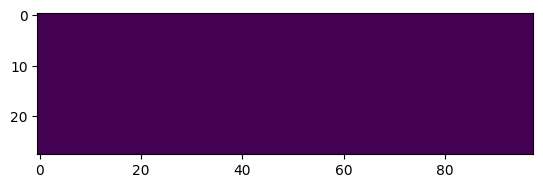

In [83]:


def residual_roe():
    nx_L,ny_L = self.get_normal_directions(direction="right")
    nx_R,ny_R = self.get_normal_directions(direction="left")
    nx_U,ny_U = self.get_normal_directions(direction="up")
    nx_D,ny_D = self.get_normal_directions(direction="down")

    V = self.V

    FL_cell_L = V[:,1:-1,0:-2]
    FL_cell_R = V[:,1:-1,1:-1]
    FL = self.compute_roe_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,:-1],ny_L[:,:-1])

    FL_cell_L = V[:,1:-1,1:-1]
    FL_cell_R = V[:,1:-1,2:]
    FR = self.compute_roe_flux_cell(FL_cell_L,FL_cell_R,nx_R[:,1:],ny_R[:,1:])

    FD_cell_L = V[:, 0:-2, 1:-1]
    FD_cell_R = V[:, 1:-1, 1:-1]
    FD = self.compute_roe_flux_cell(FD_cell_L, FD_cell_R, nx_D[0:-1,:], ny_D[0:-1,:])
    # Flux up
    FU_cell_L = V[:,1:-1 , 1:-1]
    FU_cell_R = V[:, 2:, 1:-1]
    FU = self.compute_roe_flux_cell(FU_cell_L, FU_cell_R, nx_U[1:,:], ny_U[1:,:]) 


    residual = -FL*self.A_left + FR*self.A_right + FU*self.A_top -FD*self.A_bottom
    return residual
plt.imshow(residual[1])

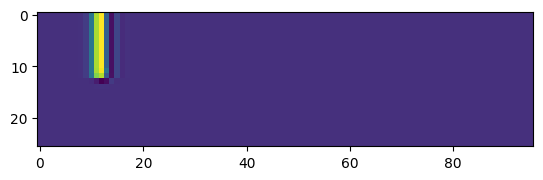

In [157]:
V = self.V



def residual_vanleer():
    V = self.V
    nx_L,ny_L = self.get_normal_directions(direction="right")
    nx_R,ny_R = self.get_normal_directions(direction="right")
    nx_U,ny_U = self.get_normal_directions(direction="up")
    nx_D,ny_D = self.get_normal_directions(direction="up")
    FL_cell_L = V[:,1:-1,0:-2]
    FL_cell_R = V[:,1:-1,1:-1]
    FL = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_L[:,:-1],ny_L[:,:-1])+self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,:-1],ny_L[:,:-1])

    FL_cell_L = V[:,1:-1,1:-1]
    FL_cell_R = V[:,1:-1,2:]
    FR = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_R[:,1:],ny_R[:,1:])+self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_R[:,1:],ny_R[:,1:])

    FD_cell_L = V[:, 0:-2, 1:-1]
    FD_cell_R = V[:, 1:-1, 1:-1]
    FD = self.f_convective_cell(FD_cell_L, FD_cell_R, nx_D[0:-1,:], ny_D[0:-1,:]) + self.f_pressure_flux_cell(FD_cell_L, FD_cell_R, nx_D[0:-1,:], ny_D[0:-1,:])

    # Flux up
    FU_cell_L = V[:,1:-1 , 1:-1]
    FU_cell_R = V[:, 2:, 1:-1]
    FU = self.f_convective_cell(FU_cell_L, FU_cell_R, nx_U[1:,:], ny_U[1:,:]) + self.f_pressure_flux_cell(FU_cell_L, FU_cell_R, nx_U[1:, :], ny_U[1:, :])




    residual = -FL*self.A_left + FR*self.A_right + FU*self.A_top- FD*self.A_bottom
    return residual
plt.imshow(residual[1])

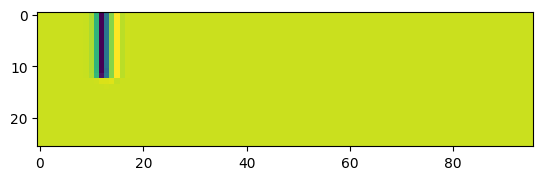

In [158]:
FL_cell_L = V[:,1:-1,0:-2]
FL_cell_R = V[:,1:-1,1:-1]
FL = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_L[:,:-1],ny_L[:,:-1])+self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,:-1],ny_L[:,:-1])

FL_cell_L = V[:,1:-1,1:-1]
FL_cell_R = V[:,1:-1,2:]
FR = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_R[:,1:],ny_R[:,1:])+self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_R[:,1:],ny_R[:,1:])

plt.imshow(FL[0])

In [159]:
rho = self.V[0]
u = self.V[1]
v = self.V[2]
p = self.V[3]
E = p / ((gamma - 1.0) * rho) + 0.5 * (u**2 + v**2)

F = np.array([rho * u, rho * u**2 + p,rho * u * v,(rho * E + p) * u])

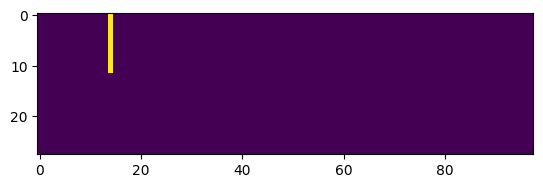

In [160]:
plt.imshow(F[1])

In [175]:
nx_L,ny_L = self.get_normal_directions(direction="right")
nx_R,ny_R = self.get_normal_directions(direction="left")
nx_U,ny_U = self.get_normal_directions(direction="up")
nx_D,ny_D = self.get_normal_directions(direction="down")
V = self.V





FL_cell_L = V[:,1:-1,0:-2]
FL_cell_R = V[:,1:-1,1:-1]
FR_cell_L = V[:,1:-1,1:-1]
FR_cell_R = V[:,1:-1,2:]
FD_cell_L = V[:, 0:-2, 1:-1]   
FD_cell_R = V[:, 1:-1, 1:-1]  
FU_cell_L = V[:, 1:-1, 1:-1]   
FU_cell_R = V[:, 2:  , 1:-1]   

FL = self.vanleer_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,0:-1],ny_L[:,0:-1])
FR = self.vanleer_flux_cell(FR_cell_L,FR_cell_R,nx_R[:,1:],ny_R[:,1:])
FD = self.vanleer_flux_cell(FD_cell_L, FD_cell_R,nx_D[0:-1, :], ny_D[0:-1, :])
FU = self.vanleer_flux_cell(FU_cell_L, FU_cell_R,nx_U[1:,:], ny_U[1:, :])

residual = ((FU[:,:,:]*self.A_top[0])+(FD[:,:,:]*self.A_bottom[0]))+((FR[:,:,:]*self.A_right[0])+(FL[:,:,]*self.A_left[0]))
#Eresidual  = self.compute_residual_cell()

In [176]:
self.compute_residual_cell()

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [177]:
FU[:,:,:]*self.A_top[0]

array([[[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        ...,
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ]],

       [[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        ...,
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ]],

       [[0.0625 , 0.0625 , 0.0625 , ..., 0.00625, 0.00625, 0.00625],
        [0.0625 , 0.0625 , 0.0625 , ..., 0.00625, 0.00625, 0.00625],
    

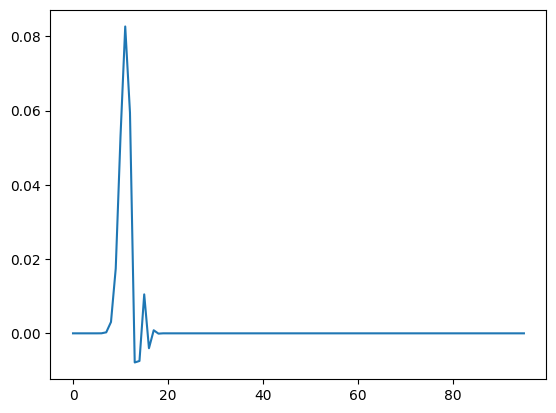

In [178]:
#residual = residual_vanleer()
#plt.imshow(residual[3,::-1])

plt.plot(residual[1,4,:])

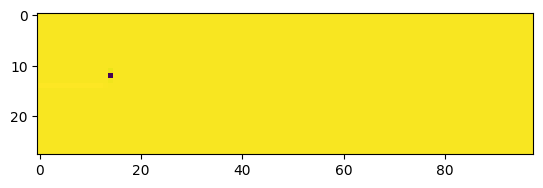

In [179]:
plt.imshow(self.V[2])

In [180]:
#residual = residual_vanleer()


In [181]:


self.U[:,1:-1,1:-1] = self.U[:,1:-1,1:-1]-(residual*.01/(self.AREA))

self.U[:, 1:-1, 0] = 2 * self.U[:, 1:-1, 1] - self.U[:, 1:-1, 2]
self.U[:, 1:-1, -1] = 2 * self.U[:, 1:-1, -2] - self.U[:, 1:-1, -3]

# Extrapolate bottom/top faces (y = 0 and y = -1), excluding boundaries in x
self.U[:, 0, 1:-1] = 2 * self.U[:, 1, 1:-1] - self.U[:, 2, 1:-1]
self.U[:, -1, 1:-1] = 2 * self.U[:, -2, 1:-1] - self.U[:, -3, 1:-1]

# Now do the corners explicitly
# Top-left
self.U[:, 0, 0] = 2 * self.U[:, 1, 1] - self.U[:, 2, 2]
# Top-right
self.U[:, 0, -1] = 2 * self.U[:, 1, -2] - self.U[:, 2, -3]
# Bottom-left
self.U[:, -1, 0] = 2 * self.U[:, -2, 1] - self.U[:, -3, 2]
# Bottom-right
self.U[:, -1, -1] = 2 * self.U[:, -2, -2] - self.U[:, -3, -3]





mach = .5*np.ones_like(self.V[0,:,0:20])

T = self.total_T(self.gamma, mach, self.T0)
p_bndry = self.total_p(self.gamma, mach, self.p0)
rho_bndry = self.total_density(p_bndry, self.R, T)
u_bndry =  self.total_velocity(self.gamma, mach, self.R, T)
v_bndry = 0*self.total_velocity(self.gamma, mach, self.R, T)


self.V = self.conserved_to_primitive(self.U)
#self.V[:, :, 0:20] = np.array([rho_bndry, u_bndry, v_bndry, p_bndry])
self.U = self.primitive_to_conserved(self.V)



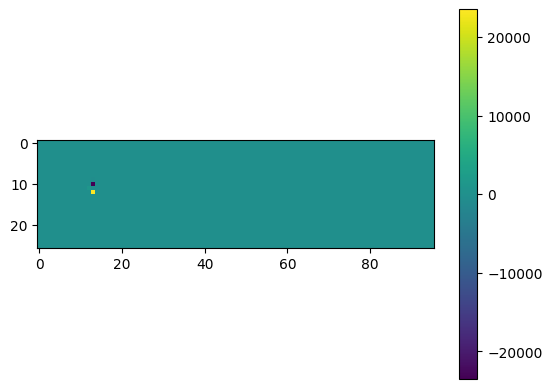

In [182]:
plt.imshow(residual[3])
plt.colorbar()

In [183]:
#FL_cell_L = V[:,1:-1,0:-2]
#FL_cell_R = V[:,1:-1,1:-1]
#FL = self.compute_roe_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,:-1],ny_L[:,:-1])

#FL_cell_L = V[:,1:-1,1:-1]
#FL_cell_R = V[:,1:-1,2:]
#FR = self.compute_roe_flux_cell(FL_cell_L,FL_cell_R,nx_R[:,1:],ny_R[:,1:])

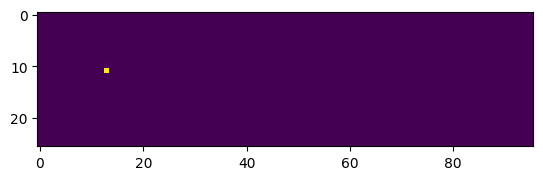

In [184]:
plt.imshow(FL[2])

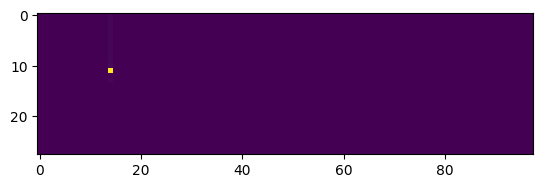

In [185]:
plt.imshow(self.V[2]**2 +self.V[1]**2)

In [186]:
df

NameError: name 'df' is not defined

In [ ]:
plt.imshow(residual[3])

In [ ]:
plt.imshow(self.residual[2])
plt.colorbar()

In [ ]:
#FR = self.f_convective(direction="right")+self.f_pressure_flux(direction="right")
#FL = self.f_convective(direction="left")+self.f_pressure_flux(direction="left")
tempV = FL+FR

In [ ]:
for i in range(11,16):
    for j in range(11,16):
        self.V[:,i,j] = (np.array([100,0,0,100],dtype=np.float64,order="F"))

self.U = self.primitive_to_conserved(self.V)
#self.iteration_step()
plt.imshow(self.U[2])
plt.colorbar()

In [ ]:
plt.imshow(self.U[3])

In [ ]:
self.residual.shape

In [ ]:
plt.imshow(self.U[2])

In [ ]:
F_plus_1_2 = (A_plus_1_2*(self.f_convective(direction="right")+self.f_pressure_flux(direction="right")))
F_minus_1_2 = (A_minus_1_2*(self.f_convective(direction="left")+self.f_pressure_flux(direction="left")))
F_UP = (A_UP*(self.f_convective(direction="up")+self.f_pressure_flux(direction="up")))
F_DOWN = (A_DOWN*(self.f_convective(direction="down")+self.f_pressure_flux(direction="down")))


F_plus_1_2+F_minus_1_2

In [ ]:
self.CFL = .000001
#self.iteration_step()
F_plus_1_2 = (A_plus_1_2*(self.f_convective(direction="right")+self.f_pressure_flux(direction="right")))
F_minus_1_2 = (A_minus_1_2*(self.f_convective(direction="left")+self.f_pressure_flux(direction="left")))
F_plus_1_2[0,0]+F_minus_1_2[0,0]

In [ ]:
F_plus_1_2 = (A_plus_1_2*(self.f_convective(direction="right")+self.f_pressure_flux(direction="right")))
F_minus_1_2 = (A_minus_1_2*(self.f_convective(direction="left")+self.f_pressure_flux(direction="left")))
S = F_plus_1_2 + F_minus_1_2
S[:,:,1:]-S[:,:,0:-1]

In [ ]:
residual[:,1:-1,1:] +=F_plus_1_2
residual[:,1:-1,0:-1]+=F_minus_1_2
residual[:,1:,1:-1]+=F_UP
residual[:,0:-1,1:-1]+=F_DOWN
        
        

In [ ]:
F_plus_1_2+F_minus_1_2

In [ ]:
self.set_inflow_conditions(direction="right",boundary_mach=.075)
self.iteration_step()
plt.imshow(self.V[0])

2


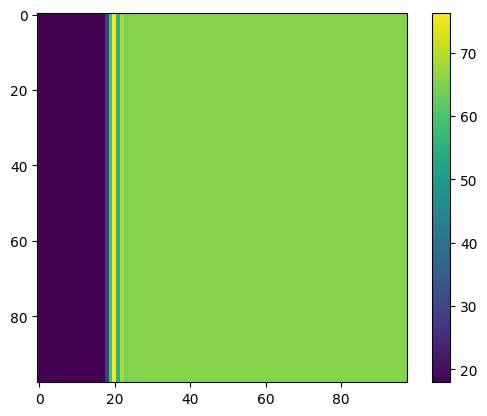

In [ ]:
self.CFL = .1
self.iteration_step()
plt.imshow(self.V[3])
plt.colorbar()

In [ ]:
self.f_convective(direction="right")[:,1:]+self.f_convective(direction="left")[:,:-1]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [ ]:
shift = self.FLUXL_FLUXR_FUNC(direction="left")
VL_mine,VR_mine = np.array([shift(self.V[i]) for i in range(4)])[:,0,:,:],np.array([shift(self.V[i]) for i in range(4)])[:,1,:,:]






ValueError: operands could not be broadcast together with shapes (96,96) (94,95) 

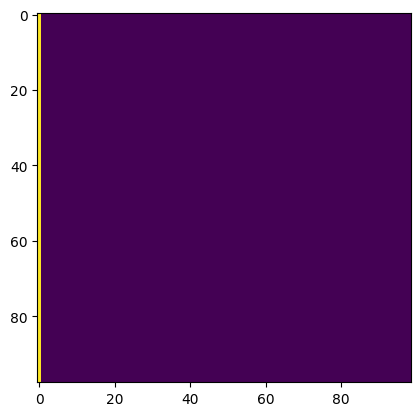

In [ ]:
plt.imshow(Fx[0])

IndentationError: unindent does not match any outer indentation level (<string>, line 282)

Configuration 1, Sod's Problem
40


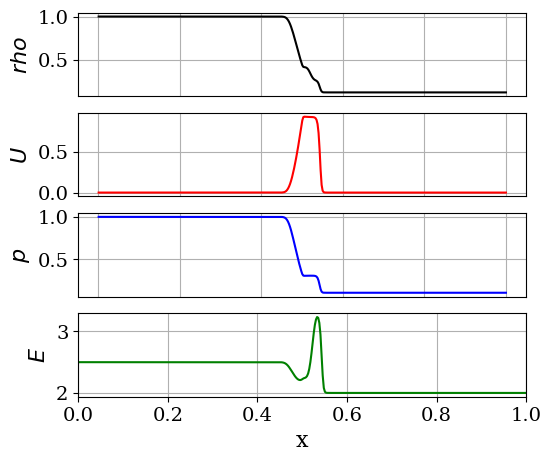

80


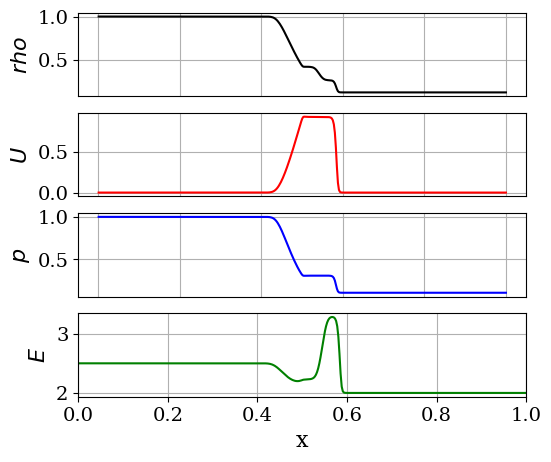

120


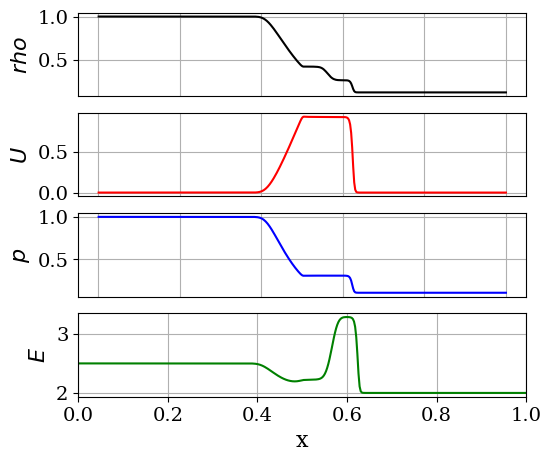

160


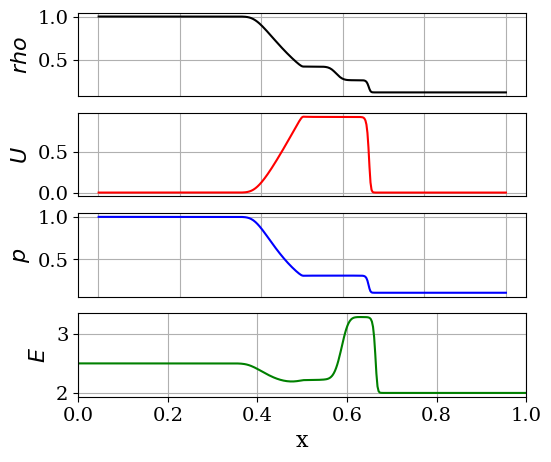

200


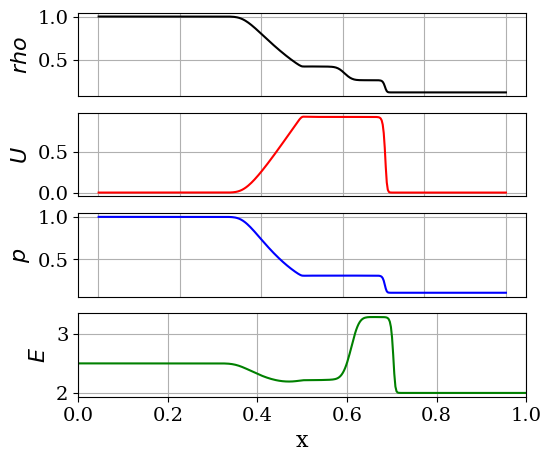

240


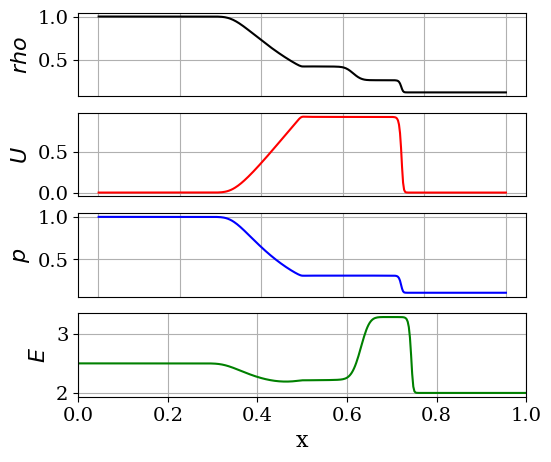

280


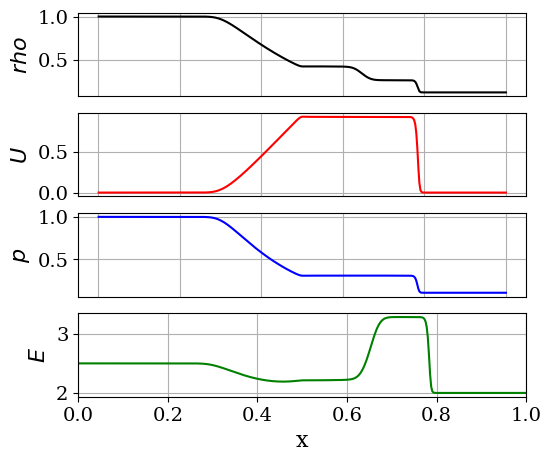

320


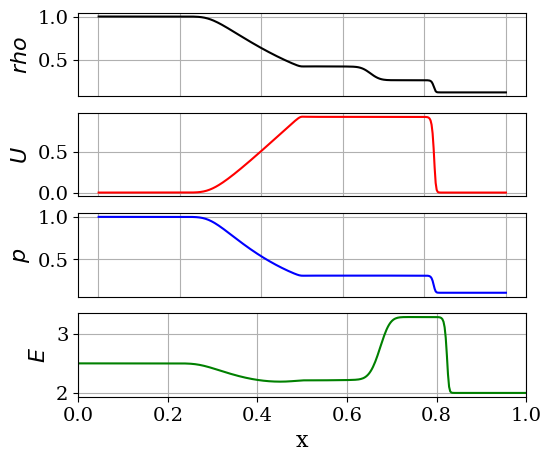

In [ ]:
#! /usr/bin/env python
# -*- coding:utf-8 -*-

################################################################
#
# Class 07: Solve the 1D-Euler system of equations using the Roe scheme
# Book: "The minimum you need to know to write your own CFD solver"
# Author: Pedro Stefanin Volpiani
# Online course: https://youtu.be/F_PsFHvt8IU
#
################################################################

import numpy as np
import matplotlib.pyplot as plt

from numpy import *
from matplotlib import rc

rc('font', family='serif', size=14)
rc('lines', linewidth=1.5)

################################################################
#             Solve the 1D-Euler system of equations
#                    using the Roe scheme
#
#             dq_i/dt + df_i/dx = 0, for x \in [a,b]
#
# This code solves the Sod's shock tube problem (IC=1)
#
#    t=0                          t=tEnd
#    Density                      Density
#    **********|                  *******\
#              |                          \
#              |                           \
#              |                            ****|
#              |                                |
#              |                                ****|
#              **********                           ********
#
# Domain cells (I{i}) reference:
#
#              |           |   u(i)    |           |
#              |  u(i-1)   |___________|           |
#              |___________|           |   u(i+1)  |
#              |           |           |___________|
#           ...|-----0-----|-----0-----|-----0-----|...
#              |    i-1    |     i     |    i+1    |
#              |-         +|-         +|-         +|
#            i-3/2       i-1/2       i+1/2       i+3/2
#
################################################################

#===============================================================
# We need a function to compute the flux vector
#===============================================================
def func_flux(q,gamma):
    # Primitive variables
    r=q[0];
    u=q[1]/r;
    v = q[2]*0
    E=q[3]/r;
    p=(gamma-1.)*r*(E-0.5*u**2);
    
    # Flux vector
    F0 = np.array(r*u)
    F1 = np.array(r*u**2+p)
    F2 = np.array(u*(r*E+p))
    flux=np.array([ F0, F1,F1*0, F2 ])
    
    return (flux)

#===============================================================
# We need a function to compute the Roe flux
#===============================================================
def flux_roe(q,dx,gamma,a,nx,LR = 1):

    # Compute primitive variables and enthalpy
    r=q[0];
    u=LR*q[1]/r;
    v = q[1]*0
    E=q[3]/r;
    p=(gamma-1.)*r*(E-0.5*u**2);
    htot = gamma/(gamma-1)*p/r+0.5*u**2
    
    # Initialize Roe flux
    Phi=np.zeros((4,nx-1))
    
    for j in range (0,nx-1):
    
        # Compute Roe averages
        R=sqrt(r[j+1]/r[j]);                          # R_{j+1/2}
        rmoy=R*r[j];                                  # {hat rho}_{j+1/2}
        umoy=(R*u[j+1]+u[j])/(R+1);                   # {hat U}_{j+1/2}
        hmoy=(R*htot[j+1]+htot[j])/(R+1);             # {hat H}_{j+1/2}
        amoy=sqrt((gamma-1.0)*(hmoy-0.5*umoy*umoy));  # {hat a}_{j+1/2}
        
        # Auxiliary variables used to compute P_{j+1/2}^{-1}
        alph1=(gamma-1)*umoy*umoy/(2*amoy*amoy);
        alph2=(gamma-1)/(amoy*amoy);

        # Compute vector (W_{j+1}-W_j)
        wdif = q[:,j+1]-q[:,j];
        
        # Compute matrix P^{-1}_{j+1/2}
                # P^{-1}
        Pinv = np.array([
            [0.5*(alph1+umoy/amoy),   -0.5*(alph2*umoy+1/amoy),   0.0,  alph2/2],
            [1 - alph1,                alph2*umoy,                0.0, -alph2   ],
            [0.0,                      0.0,                       0.0,  0.0     ],
            [0.5*(alph1-umoy/amoy),   -0.5*(alph2*umoy-1/amoy),   0.0,  alph2/2 ]
        ])

        # P
        P = np.array([
            [1.0,           1.0,          0.0,           1.0           ],
            [umoy-amoy,     umoy,         0.0,           umoy+amoy     ],
            [0.0,           0.0,          0.0,           0.0           ],
            [hmoy-amoy*umoy,0.5*umoy*umoy,0.0,           hmoy+amoy*umoy]
        ])

        # Λ
        lamb = np.array([
            [abs(umoy-amoy), 0.0, 0.0,               0.0             ],
            [0.0,            abs(umoy), 0.0,         0.0             ],
            [0.0,            0.0,       0.0,         0.0             ],
            [0.0,            0.0,       0.0,         abs(umoy+amoy)  ]
        ])

                      
        # Compute Roe matrix |A_{j+1/2}|
        A=np.dot(P,lamb)
        A=np.dot(A,Pinv)
        
        # Compute |A_{j+1/2}| (W_{j+1}-W_j)
        Phi[:,j]=np.dot(A,wdif)
        
    # Compute Phi=(F(W_{j+1}+F(W_j))/2-|A_{j+1/2}| (W_{j+1}-W_j)/2
    F = func_flux(q,gamma);
    Phi=0.5*(F[:,0:nx-1]+F[:,1:nx])-0.5*Phi
    
    
    return Phi

#===============================================================
# Parameters
#===============================================================
CFL    = 0.50               # Courant Number
gamma  = 1.4                # Ratio of specific heats
tEnd = 0.20                 # Final time
ncells = 400                # Number of cells
x_ini =0.; x_fin = 1.       # Limits of computational domain
dx = (x_fin-x_ini)/ncells   # Step size
nx = ncells+1               # Number of points
x = np.linspace(x_ini+dx/2.,x_fin,nx) # Mesh

#===============================================================
# Initial conditions
#===============================================================
r0 = np.zeros(nx)
u0 = np.zeros(nx)
p0 = np.zeros(nx)
halfcells = int(ncells/2)

print ("Configuration 1, Sod's Problem")
p0[:halfcells] = 1.0  ; p0[halfcells:] = 0.1;
u0[:halfcells] = 0.0  ; u0[halfcells:] = 0.0;
r0[:halfcells] = 1.0  ; r0[halfcells:] = 0.125;

E0 = p0/((gamma-1.)*r0)+0.5*u0**2 # Total Energy density
a0 = sqrt(gamma*p0/r0)            # Speed of sound
q  = np.array([r0,r0*u0,0*u0,r0*E0])   # Vector of conserved variables

#===============================================================
# Solver loop
#===============================================================
t  = 0
it = 0
a  = a0
dt=CFL*dx/max(abs(u0)+a0)         # Using the system's largest eigenvalue

while t < tEnd:

    q0 = q.copy();
    dF =  flux_roe(q0,dx,gamma,a,nx,LR=1)[:,1:-1]-flux_roe(q0,dx,gamma,a,nx,LR=1)[:,0:-2]

    q[:,1:-2] = q0[:,1:-2]-dt/dx*dF;
    q[:,0]=q0[:,0]; q[:,-1]=q0[:,-1]; # Dirichlet BCs
    
    # Compute primary variables
    rho=q[0];
    u=q[1]/rho;
    E=q[3]/rho;
    p=(gamma-1.)*rho*(E-0.5*u**2);
    a=sqrt(gamma*p/rho);
    if min(p)<0: print ('negative pressure found!')
    
    # Update/correct time step
    dt=CFL*dx/max(abs(u)+a);
    
    # Update time and iteration counter
    t=t+dt; it=it+1;
        
    # Plot solution
    if it%40 == 0:
        print (it)
        fig,axes = plt.subplots(nrows=4, ncols=1)
        plt.subplot(4, 1, 1)
        #plt.title('Roe scheme')
        plt.plot(x, rho, 'k-')
        plt.ylabel('$rho$',fontsize=16)
        plt.tick_params(axis='x',bottom=False,labelbottom=False)
        plt.grid(True)

        plt.subplot(4, 1, 2)
        plt.plot(x, u, 'r-')
        plt.ylabel('$U$',fontsize=16)
        plt.tick_params(axis='x',bottom=False,labelbottom=False)
        plt.grid(True)

        plt.subplot(4, 1, 3)
        plt.plot(x, p, 'b-')
        plt.ylabel('$p$',fontsize=16)
        plt.tick_params(axis='x',bottom=False,labelbottom=False)
        plt.grid(True)
    
        plt.subplot(4, 1, 4)
        plt.plot(x, E, 'g-')
        plt.ylabel('$E$',fontsize=16)
        plt.grid(True)
        plt.xlim(x_ini,x_fin)
        plt.xlabel('x',fontsize=16)
        plt.subplots_adjust(left=0.2)
        plt.subplots_adjust(bottom=0.15)
        plt.subplots_adjust(top=0.95)
        plt.show()
        #fig.savefig("fig_Sod_Roe_it"+str(it)+".pdf", dpi=300)

In [ ]:
flux_roe(self.V[:,0,:],dx=dx,gamma=1.4,a=a,nx=nx)

/tmp/ipykernel_1889051/1513009550.py:95: RuntimeWarning: invalid value encountered in sqrt
  amoy=sqrt((gamma-1.0)*(hmoy-0.5*umoy*umoy));  # {hat a}_{j+1/2}


IndexError: index 98 is out of bounds for axis 0 with size 98